In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests
from io import StringIO

pd.options.mode.copy_on_write = True

# Bygninger og Energiforbruk - Årlig oppløsning per byggeår

Henter data fra SSB for **2022**:
- **06266**: Antall eneboliger etter byggeår
- **10576**: Gjennomsnittlig energiforbruk per husholdning etter energibærer og byggeår

Splitter begge datasett til årlig oppløsning:
- **Antall boliger** (sum) → fordeles jevnt over årene i intervallet
- **Energiforbruk** (gjennomsnitt) → kopieres til hvert år i intervallet

In [33]:
# Hent antall eneboliger per byggeår fra SSB 06266
r = requests.get("https://data.ssb.no/api/pxwebapi/v2/tables/06266/data", params={
    'lang': 'no',
    'outputformat': 'csv',
    'valueCodes[Region]': '0',
    'valueCodes[BygnType]': '01',
    'valueCodes[BygnAr]': '*',
    'valueCodes[ContentsCode]': 'Boliger',
    'valueCodes[Tid]': '2022',
})
df_buildings = pd.read_csv(StringIO(r.text)).rename(columns={'Boliger 2022': 'Boliger'})
df_buildings

,Region,BygnType,BygnAr,Boliger
0,0,1,1,79505
1,0,1,2,48140
2,0,1,3,75266
3,0,1,4,8137
4,0,1,6,169835
5,0,1,7,158873
6,0,1,8,215772
7,0,1,9,195250
8,0,1,10,105851
9,0,1,11,93568


In [34]:
# Definer årsintervaller for 06266 byggeår-koder
bygn_year_ranges = {
    1:  (1900, 1900),  # 1900 og tidligere
    2:  (1901, 1920),
    3:  (1921, 1940),
    4:  (1941, 1945),
    6:  (1946, 1960),
    7:  (1961, 1970),
    8:  (1971, 1980),
    9:  (1981, 1990),
    10: (1991, 2000),
    11: (2001, 2010),
    12: (2011, 2020),
    13: (2021, 2022),
    99: (1970, 1970),  # Ukjent byggeår → tilordnet 1970
}

# Ekspansjontabell: BygnAr-kode → individuelle år + antall år i intervallet
expand_bygn = pd.DataFrame([
    {'BygnAr': code, 'year': y, 'n_years': end - start + 1}
    for code, (start, end) in bygn_year_ranges.items()
    for y in range(start, end + 1)
])

df_buildings_yearly = (
    df_buildings
    .merge(expand_bygn, on='BygnAr')
    .assign(antall_boliger=lambda d: d['Boliger'] / d['n_years'])
    .groupby('year', as_index=False)['antall_boliger'].sum()
    .sort_values('year')
    .reset_index(drop=True)
)
print(f"{len(df_buildings_yearly)} årlige rader")
df_buildings_yearly

123 årlige rader


/Users/marcus/repositories/Beregninger_Scenariomodell/.venv/lib/python3.14/site-packages/pandas/core/frame.py:5246: ChainedAssignmentError: A value is trying to be set on a copy of a DataFrame or Series through chained assignment.
When using the Copy-on-Write mode, such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy.

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[k] = com.apply_if_callable(v, data)


,year,antall_boliger
0,1900,79505.0
1,1901,2407.0
2,1902,2407.0
3,1903,2407.0
4,1904,2407.0
...,...,...
118,2018,7683.3
119,2019,7683.3
120,2020,7683.3
121,2021,3052.0


In [45]:
# Hent energiforbruk per husholdning fra SSB 10576
meta_energy = requests.get("https://data.ssb.no/api/pxwebapi/v2/tables/10576/metadata?lang=no")
energy_labels = meta_energy.json()['dimension']['Energibaerer']['category']['label']

r = requests.get("https://data.ssb.no/api/pxwebapi/v2/tables/10576/data", params={
    'lang': 'no',
    'outputformat': 'csv',
    'valueCodes[Energibaerer]': '*',
    'valueCodes[ByggeAar]': '*',
    'valueCodes[ContentsCode]': 'Forbruk',
    'valueCodes[Tid]': '2022',
})
df_energy = (
    pd.read_csv(StringIO(r.text))
    .rename(columns={'Forbruk 2022': 'Forbruk'})
    .assign(Forbruk=lambda d: pd.to_numeric(d['Forbruk'], errors='coerce'))
)
df_energy

/Users/marcus/repositories/Beregninger_Scenariomodell/.venv/lib/python3.14/site-packages/pandas/core/frame.py:5246: ChainedAssignmentError: A value is trying to be set on a copy of a DataFrame or Series through chained assignment.
When using the Copy-on-Write mode, such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy.

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[k] = com.apply_if_callable(v, data)


,Energibaerer,ByggeAar,Forbruk
0,0,30,17264.0
1,0,31,18110.0
2,0,51,17292.0
3,0,71,18737.0
4,0,81,20177.0
5,0,91,16498.0
6,0,92,14427.0
7,1.1,30,14385.0
8,1.1,31,14935.0
9,1.1,51,14642.0


In [36]:
# Definer årsintervaller for 10576 byggeår-koder
energy_year_ranges = {
    30: (1900, 1930),   # Før 1931
    31: (1931, 1954),
    51: (1955, 1970),
    71: (1971, 1986),
    81: (1987, 1996),
    91: (1997, 2009),
    92: (2010, 2022),
}

# Ekspansjontabell: ByggeAar-kode → individuelle år
expand_energy = pd.DataFrame([
    {'ByggeAar': code, 'year': y}
    for code, (start, end) in energy_year_ranges.items()
    for y in range(start, end + 1)
])

# Pivot energibærer → kolonner, deretter ekspander til årlig
df_energy_wide = (
    df_energy
    .pivot(index='ByggeAar', columns='Energibaerer', values='Forbruk')
    .rename(columns=energy_labels)
    .reset_index()
)

df_energy_yearly = (
    df_energy_wide
    .merge(expand_energy, on='ByggeAar')
    .drop(columns='ByggeAar')
    .sort_values('year')
    .reset_index(drop=True)
)
print(f"{len(df_energy_yearly)} årlige rader")
df_energy_yearly

123 årlige rader


,I alt,Elektrisitet,"Ved, pellets og vedbriketter",Olje og parafin,Gass og fjernvarme,year
0,17264.0,14385.0,2627.0,NaN,224.0,1900
1,17264.0,14385.0,2627.0,NaN,224.0,1901
2,17264.0,14385.0,2627.0,NaN,224.0,1902
3,17264.0,14385.0,2627.0,NaN,224.0,1903
4,17264.0,14385.0,2627.0,NaN,224.0,1904
...,...,...,...,...,...,...
118,14427.0,12559.0,882.0,NaN,948.0,2018
119,14427.0,12559.0,882.0,NaN,948.0,2019
120,14427.0,12559.0,882.0,NaN,948.0,2020
121,14427.0,12559.0,882.0,NaN,948.0,2021


In [37]:
# Merge bygningsdata og energidata på byggeår
df = (
    df_buildings_yearly
    .merge(df_energy_yearly, on='year', how='left')
    .sort_values('year')
    .reset_index(drop=True)
)
df

,year,antall_boliger,I alt,Elektrisitet,"Ved, pellets og vedbriketter",Olje og parafin,Gass og fjernvarme
0,1900,79505.0,17264.0,14385.0,2627.0,NaN,224.0
1,1901,2407.0,17264.0,14385.0,2627.0,NaN,224.0
2,1902,2407.0,17264.0,14385.0,2627.0,NaN,224.0
3,1903,2407.0,17264.0,14385.0,2627.0,NaN,224.0
4,1904,2407.0,17264.0,14385.0,2627.0,NaN,224.0
...,...,...,...,...,...,...,...
118,2018,7683.3,14427.0,12559.0,882.0,NaN,948.0
119,2019,7683.3,14427.0,12559.0,882.0,NaN,948.0
120,2020,7683.3,14427.0,12559.0,882.0,NaN,948.0
121,2021,3052.0,14427.0,12559.0,882.0,NaN,948.0


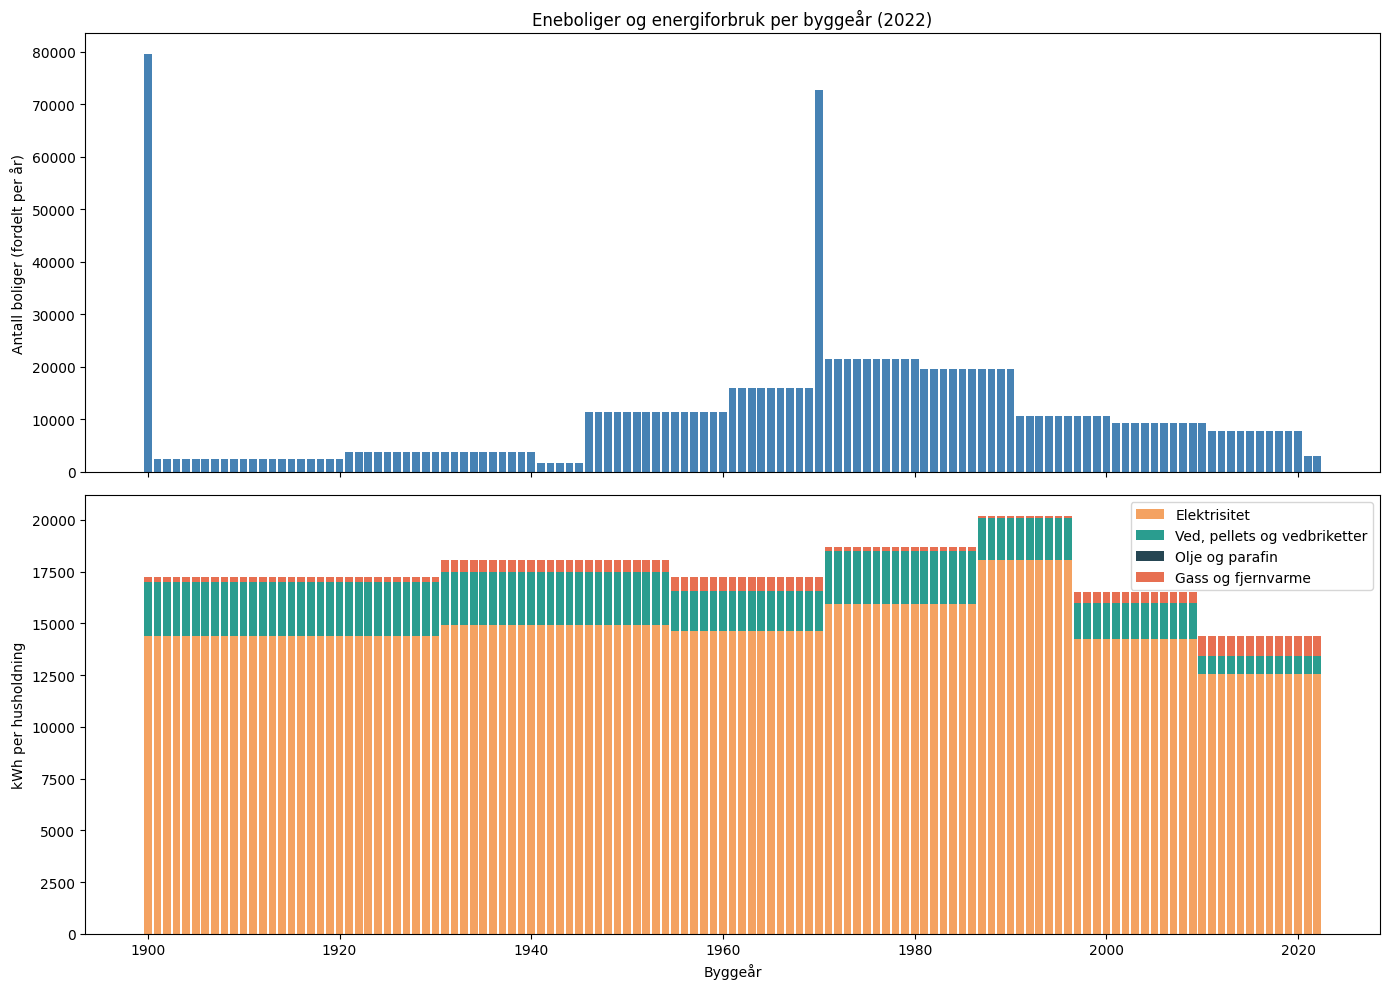

In [38]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.bar(df['year'], df['antall_boliger'], color='steelblue', width=0.8)
ax1.set_ylabel('Antall boliger (fordelt per år)')
ax1.set_title('Eneboliger og energiforbruk per byggeår (2022)')

energy_plot_cols = ['Elektrisitet', 'Ved, pellets og vedbriketter', 'Olje og parafin', 'Gass og fjernvarme']
colors = ['#f4a261', '#2a9d8f', '#264653', '#e76f51']
bottom = np.zeros(len(df))
for col, color in zip(energy_plot_cols, colors):
    vals = df[col].fillna(0).values
    ax2.bar(df['year'], vals, bottom=bottom, label=col, color=color, width=0.8)
    bottom += vals

ax2.set_xlabel('Byggeår')
ax2.set_ylabel('kWh per husholdning')
ax2.legend()

plt.tight_layout()
plt.show()

In [39]:
df

,year,antall_boliger,I alt,Elektrisitet,"Ved, pellets og vedbriketter",Olje og parafin,Gass og fjernvarme
0,1900,79505.0,17264.0,14385.0,2627.0,NaN,224.0
1,1901,2407.0,17264.0,14385.0,2627.0,NaN,224.0
2,1902,2407.0,17264.0,14385.0,2627.0,NaN,224.0
3,1903,2407.0,17264.0,14385.0,2627.0,NaN,224.0
4,1904,2407.0,17264.0,14385.0,2627.0,NaN,224.0
...,...,...,...,...,...,...,...
118,2018,7683.3,14427.0,12559.0,882.0,NaN,948.0
119,2019,7683.3,14427.0,12559.0,882.0,NaN,948.0
120,2020,7683.3,14427.0,12559.0,882.0,NaN,948.0
121,2021,3052.0,14427.0,12559.0,882.0,NaN,948.0


In [40]:
df.drop(columns='Olje og parafin').rename(columns={'year': 'byggeaar'}).to_csv('data/bygningsbestand_2022.csv', index=False)
df

,year,antall_boliger,I alt,Elektrisitet,"Ved, pellets og vedbriketter",Olje og parafin,Gass og fjernvarme
0,1900,79505.0,17264.0,14385.0,2627.0,NaN,224.0
1,1901,2407.0,17264.0,14385.0,2627.0,NaN,224.0
2,1902,2407.0,17264.0,14385.0,2627.0,NaN,224.0
3,1903,2407.0,17264.0,14385.0,2627.0,NaN,224.0
4,1904,2407.0,17264.0,14385.0,2627.0,NaN,224.0
...,...,...,...,...,...,...,...
118,2018,7683.3,14427.0,12559.0,882.0,NaN,948.0
119,2019,7683.3,14427.0,12559.0,882.0,NaN,948.0
120,2020,7683.3,14427.0,12559.0,882.0,NaN,948.0
121,2021,3052.0,14427.0,12559.0,882.0,NaN,948.0


In [41]:
carbon_intensities = { ### temporary guesses
    'Elektrisitet':                   0.250,   # Europe grid mix gCO2/kWh → kg
    'Olje og parafin':                0.267,   # Heating oil ~267 gCO2/kWh
    'Ved, pellets og vedbriketter':   0.0,     # Biogenic, typically counted as 0 in national accounts
    'Gass og fjernvarme':             0.130,   # Rough mix; district heating varies by source
}

energy_cols = list(carbon_intensities.keys())

for col in energy_cols:
    df[f'emissions_{col}'] = df['antall_boliger'] * df[col].fillna(0) * carbon_intensities[col]

emission_cols = [f'emissions_{col}' for col in energy_cols]
df['total_emissions_kg'] = df[emission_cols].sum(axis=1)

total_tco2 = df['total_emissions_kg'].sum() / 1e3
print(f"Total CO2 fra eneboliger (2022): {total_tco2:,.0f} tonn CO2")

Total CO2 fra eneboliger (2022): 4,960,836 tonn CO2


In [42]:
meta = requests.get("https://data.ssb.no/api/pxwebapi/v2/tables/06265/metadata?lang=no")
meta.json()

{'version': '2.0',
 'class': 'dataset',
 'label': '06265: Boliger, etter bygningstype (K) 2006-2025',
 'source': 'Statistisk sentralbyrå',
 'updated': '2025-03-04T07:00:00Z',
 'note': ['Populasjon: \nNye tall for  boligpopulasjon 2012, 2013, 2014, 2015 og 2016. Modell for avgrensing av boligpopulasjonen er noe endret, slik at det blir et brudd i statistikken før og etter 2012. Boligpopulasjonen avgrenses vha Matrikkelen og Folkeregisteret. Kjennemerkene som brukes er bygningstype, bygningsstatus, bruksenhetstype og hvorvidt det er registrert bosatte i bruksenhet eller bygning. Fritidsboliger og bruksenheter registrert som annet enn bolig inkluderes i statistikken dersom det ifølge folkeregisteret er registrert bosatte på boligens adresse.  Folkeregisteret brukes også til å overstyre informasjon, eksempelvis ved manglende ferdigattest, dersom det er registrert bosatte i bygningen. I tillegg imputeres boliger i boligbygninger med registrert bosatte men uten registrerte bruksenheter.',
  

In [43]:
meta = requests.get("https://data.ssb.no/api/pxwebapi/v2/tables/10576/metadata?lang=no")
meta.json()

{'version': '2.0',
 'class': 'dataset',
 'label': '10576: Gjennomsnittlig energiforbruk per husholdning, etter energibærer og byggeår 2009-2022',
 'source': 'Statistisk sentralbyrå',
 'updated': '2025-07-23T06:00:00Z',
 'note': ['For året 2012 er boliger bygget fra og med 2010 inkludert i 1997-2009.'],
 'role': {'time': ['Tid'], 'metric': ['ContentsCode']},
 'id': ['Energibaerer', 'ByggeAar', 'ContentsCode', 'Tid'],
 'size': [5, 7, 1, 3],
 'dimension': {'Energibaerer': {'label': 'energibærer',
   'category': {'index': {'0': 0, '1.1': 1, '3.0': 2, '2.01': 3, '4-5': 4},
    'label': {'0': 'I alt',
     '1.1': 'Elektrisitet',
     '3.0': 'Olje og parafin',
     '2.01': 'Ved, pellets og vedbriketter',
     '4-5': 'Gass og fjernvarme'}},
   'extension': {'elimination': True, 'show': 'value', 'codelists': []}},
  'ByggeAar': {'label': 'byggeår',
   'category': {'index': {'30': 0,
     '31': 1,
     '51': 2,
     '71': 3,
     '81': 4,
     '91': 5,
     '92': 6},
    'label': {'30': 'Før 193

### LLM overviw of relevant SSB data

**Tables you already use:**

| Tabell | Innhold | Bruk |
|---|---|---|
| **06266** | Boliger etter bygningstype og byggeår (K), 2006–2025 | Boligbestand per byggeår-kohort |
| **10576** | Gj.snittlig energiforbruk per husholdning, etter energibærer og byggeår, 2009/2012/2022 | kWh per bolig per kohort |

---

**Tables you should grab for the projection:**

| Tabell | Innhold | Hva du bruker den til |
|---|---|---|
| **06265** | Boliger etter bygningstype (K), 2006–2025 | Total boligbestand over tid (enklere tidsserie enn 06266 for å se netto vekst/år) |
| **05940** | Byggeareal: fullførte boliger + bruksareal, etter bygningstype (K), 2000–2024 (årlig) | Historisk nybygging av eneboliger per år → grunnlag for fremtidig nybyggtakt |
| **10784** | Byggeareal: avgang av boliger, etter bygningstype (K), 2009K1–2024 (kvartalsvis) | Historisk rivning/avgang per år → grunnlag for rivningsrate |
| **10785** | Byggeareal: avgang av bygninger, etter bygningstype (K), 2009–2021 (årlig) | Samme som over men på bygningsnivå, årlig — enklere å bruke |
| **13929** | Energiforbruk i husholdninger og fritidshus, 1990–2024 | Total energibruk i husholdninger over tid (GWh) — god for sanity check og for å se den historiske trenden i total energibruk |
| **10573** | Gj.snittlig energiforbruk per husholdning, etter hustype, 1995–2022 | Energitrend spesifikt for eneboliger over tid (viser den naturlige nedgangen uten spesifikk etterisolering) |
| **10582** | Gj.snittlig energiforbruk per husholdning, etter energibærer og hustype, 1995–2022 | Samme som over men splittet på energibærer — viser f.eks. at olje forsvinner over tid |

---

**Nice to have (men ikke strengt nødvendig):**

| Tabell | Innhold | Eventuell bruk |
|---|---|---|
| **06513** | Boliger etter bygningstype og bruksareal (K), 2007–2025 | Areal per bolig per kohort — hvis du vil gå fra kWh/m² i stedet |
| **10571** | Husholdninger etter type hovedoppvarmingskilde (%), 1994–2022 | Viser varmepumpe-utbredelse over tid |
| **14578** | Energiforbruk per husholdning, etter energibærer, landsdel og fylke, 2022 | Regional variasjon (om relevant) |
| **13932** | Klimagasser fra norsk øk. aktivitet, etter næring (AR5/Paris) | For å kryssjekke dine utslippstall mot offisielle husholdningsutslipp |

---

De fire øverste i "bør hente"-lista er det viktigste: **05940** og **10784/10785** gir deg nybygg- og rivningsrater, **13929** gir en sanity-check på totalt energiforbruk, og **10573** viser den historiske trenden i energibruk per enebolig som du kan bruke til å kalibrere din "naturlig forbedring"-antakelse i baseline.